In [2]:
import importlib
import Multiclass_functions_1

import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
#from Multiclass_functions_1 import * # import all functions
from multiclass_Classification_2 import *
DEVICE = "mps" if torch.mps.is_available() else "cpu"

In [ ]:
importlib.reload(Multiclass_functions_1)
from Multiclass_functions_1 import * 

In [ ]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 20
criterion = nn.CrossEntropyLoss()
new_model_train = True
model_type = "CNN_deep"
dataset = "CIFAR10"
save_model_path = f'/Volumes/김상현/results/MC_CIFAR10/{model_type}_{dataset}.pt'


In [4]:
transform = transforms.ToTensor()
train_DS = datasets.CIFAR10(root = '/Volumes/김상현/dataset', train = True, download = False, transform = transform)
test_DS = datasets.CIFAR10(root = '/Volumes/김상현/dataset', train = False, download = False, transform = transform)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [6]:
print(train_DS)
print(test_DS)
print(len(train_DS))
print(len(test_DS))

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /Volumes/김상현/dataset
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /Volumes/김상현/dataset
    Split: Test
    StandardTransform
Transform: ToTensor()
50000
10000


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
torch.Size([32, 3, 32, 32])
ship


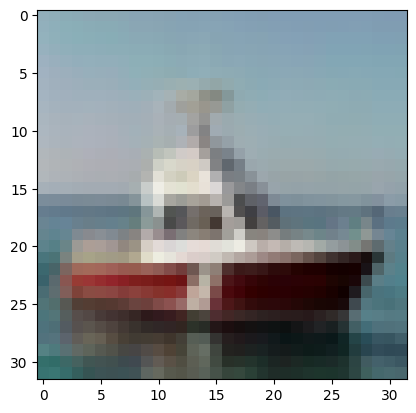

In [13]:
print(test_DS.classes)
print(test_DS.class_to_idx)
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0))
print(test_DS.classes[y_batch[0]])

### permute란?
텐서의 차원 순서를 바꿔주는 함수예요.

왜 쓰냐면
이미지 데이터는 라이브러리마다 차원 순서가 달라요.
라이브러리순서예시

PyTorch(C, H, W)(3, 256, 256)

Matplotlib/NumPy(H, W, C)(256, 256, 3)

PyTorch로 학습한 이미지를 matplotlib으로 시각화하려면 차원 순서를 바꿔줘야 해요. 그때 permute를 써요!

In [14]:
# 1. tensor 로 바꾸고
# 2. 개채행열로 바꾸고
# 3. 0~1 사이로 바꾸고 (int -> float)
print(type(train_DS.data))
print(train_DS.data.shape)
print(train_DS.data.dtype)
print(train_DS.data[0][0][0][0])
x_batch, y_batch = next(iter(train_DL)) # next(iter(train_DS)) 는 한장만 꺼내기
print(type(x_batch))
print(x_batch.shape)
print(x_batch.dtype)
print(x_batch[0][0][0][0])

<class 'numpy.ndarray'>
(50000, 32, 32, 3)
uint8
59
<class 'torch.Tensor'>
torch.Size([32, 3, 32, 32])
torch.float32
tensor(0.2941)


In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.linear = nn.Sequential(nn.Linear(3*32*32, 100),
                                    nn.ReLU(),
                                    nn.Linear(100, 10))
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x
    
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Sequential(nn.Conv2d(3, 8, 3, padding=1),
                                   nn.BatchNorm2d(8),
                                   nn.ReLU())
        
        self.Maxpool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Sequential(nn.Conv2d(8, 16, 3, padding = 1),
                                   nn.BatchNorm2d(16),
                                   nn.ReLU())
        
        self.Maxpool2 = nn.MaxPool2d(2)
        
        self.conv3 = nn.Sequential(nn.Conv2d(16, 32, 3, padding = 1),
                                   nn.BatchNorm2d(32),
                                   nn.ReLU())
        
        self.Maxpool3 = nn.MaxPool2d(2)
        
        self.fc = nn.Linear(32*4*4, 10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.Maxpool1(x)
        x = self.conv2(x)
        x = self.Maxpool2(x)
        x = self.conv3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x
    
class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1),
                                         nn.BatchNorm2d(32), # # of feature
                                         nn.ReLU(),
                                         nn.Conv2d(32,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)

        self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)
        
        # self.classifier = nn.Sequential(nn.Linear(128*4*4,512),
        #                                 nn.Linear(512,10))
        self.classifier = nn.Sequential(nn.Linear(128*4*4,512),
                                        nn.Linear(512,10))    
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        # x = torch.flatten(x, start_dim=1) # !!!!!!!
        # x = self.classifier(x)
        x = torch.flatten(x, start_dim=1) # !!!!!!!
        x = self.classifier(x)
        return x


In [43]:
x = torch.randn(32, 3, 32, 32)
model = CNN_deep()
print(model(x).shape)

torch.Size([32, 10])


```python
exec("model = MLP().to(DEVICE)")
# 실제로 이게 실행되는 것과 똑같음
model = MLP().to(DEVICE)
```

exec() 없이 직접 짜면?
→ 코드를 매번 손으로 바꿔야 함 😩

exec() 쓰면?

실행할 문자열: 'model = MLP()'    → MLP 모델 생성

실행할 문자열: 'model = CNN()'    → CNN 모델 생성

실행할 문자열: 'model = ResNet()' → ResNet 모델 생성

→ model_type 변수 하나만 바꾸면 끝! 😊

In [6]:
exec(f"model = {model_type}().to(DEVICE)")
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

CNN_deep(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=

In [7]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history, acc_history = Train(model, train_DL, criterion, optimizer, EPOCH)
    
    torch.save(model, save_model_path)

    plt.plot(range(1, EPOCH + 1), loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title("Train loss")
    plt.grid()
    plt.show()
    
    
    plt.plot(range(1, EPOCH + 1), acc_history)
    plt.xlabel('Epoch')
    plt.ylabel('Acc')
    plt.title('Train Acc')
    plt.grid()
    plt.show()

TypeError: Train() missing 6 required positional arguments: 'EPOCH', 'scheduler', 'BATCH_SIZE', 'TRAIN_RATIO', 'save_model_path', and 'save_history_path'

In [25]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

In [26]:
Test(load_model ,test_DL)
print(count_params(load_model))

Test Accuaracy: 6875/10000 (68.8%)
11274


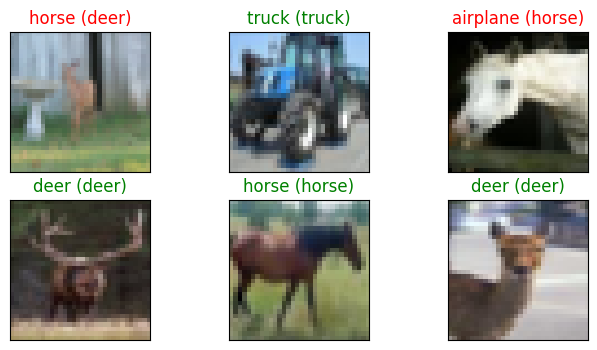

In [27]:
Test_plot(load_model, test_DL)

In [30]:
exec(f"model = {model_type}().to(DEVICE)")
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

CNN_deep(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=

Epoch: 1, train loss: 1.525
Train Accuaracy: 22374/50000 (44.7%)
--------------------
Epoch: 2, train loss: 0.95
Train Accuaracy: 33226/50000 (66.5%)
--------------------
Epoch: 3, train loss: 0.748
Train Accuaracy: 37066/50000 (74.1%)
--------------------
Epoch: 4, train loss: 0.619
Train Accuaracy: 39377/50000 (78.8%)
--------------------
Epoch: 5, train loss: 0.528
Train Accuaracy: 40977/50000 (82.0%)
--------------------
Epoch: 6, train loss: 0.458
Train Accuaracy: 41998/50000 (84.0%)
--------------------
Epoch: 7, train loss: 0.388
Train Accuaracy: 43240/50000 (86.5%)
--------------------
Epoch: 8, train loss: 0.334
Train Accuaracy: 44210/50000 (88.4%)
--------------------
Epoch: 9, train loss: 0.28
Train Accuaracy: 45010/50000 (90.0%)
--------------------
Epoch: 10, train loss: 0.238
Train Accuaracy: 45869/50000 (91.7%)
--------------------
Epoch: 11, train loss: 0.202
Train Accuaracy: 46435/50000 (92.9%)
--------------------
Epoch: 12, train loss: 0.167
Train Accuaracy: 47047/50

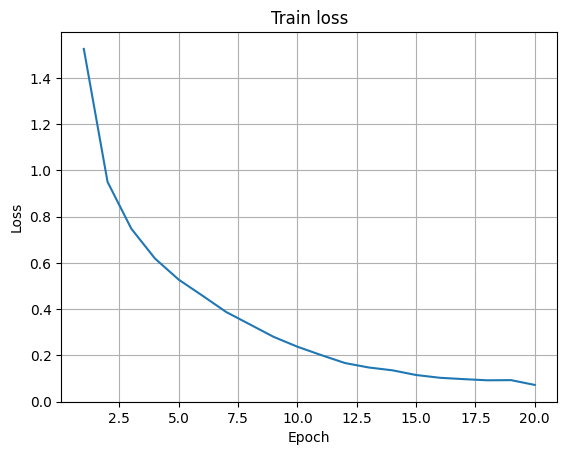

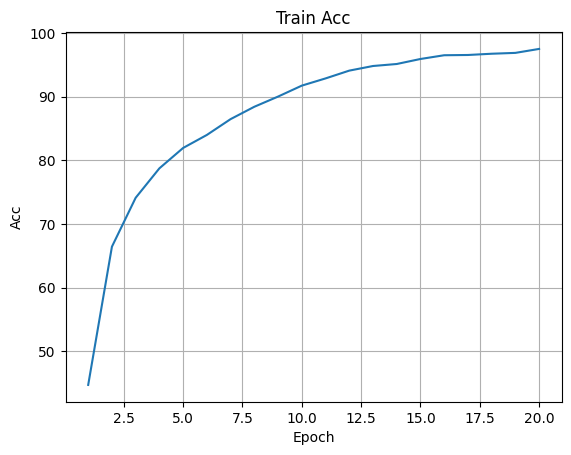

In [31]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history, acc_history = Train(model, train_DL, criterion, optimizer, EPOCH)
    
    torch.save(model, save_model_path)

    plt.plot(range(1, EPOCH + 1), loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title("Train loss")
    plt.grid()
    plt.show()
    
    
    plt.plot(range(1, EPOCH + 1), acc_history)
    plt.xlabel('Epoch')
    plt.ylabel('Acc')
    plt.title('Train Acc')
    plt.grid()
    plt.show()

In [32]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

In [33]:
Test(load_model ,test_DL)
print(count_params(load_model))

Test Accuaracy: 8209/10000 (82.1%)
1527018


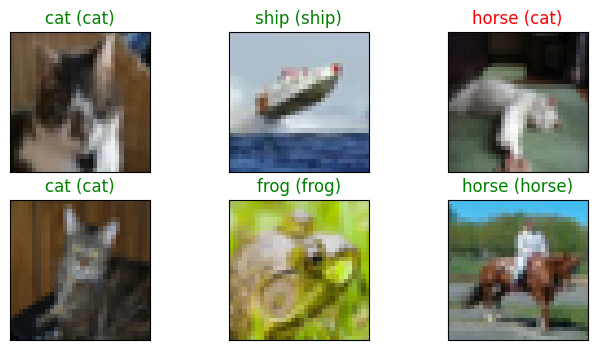

In [39]:
Test_plot(load_model, test_DL)